# Notebook 06 — Correlation & Outlier Analysis
**Feature 1.7 — EDA & Data Understanding | HitRadar Pro**

## Mục tiêu
- Tính correlation giữa `target_popularity` (label) và các numeric features.
- Phân tích outliers: duration short/long, loudness dương, tempo/time_signature NULL.
- Đưa ra đề xuất cụ thể cho Feature 1.8 / EPIC 2.

⚠️ **`target_popularity` là LABEL ML — KHÔNG dùng làm input feature.**

In [1]:
import os, warnings, psycopg2, pandas as pd, matplotlib.pyplot as plt
import matplotlib.ticker as mticker
warnings.filterwarnings('ignore', category=UserWarning)

password = os.environ.get("PGPASSWORD")
if not password:
    raise RuntimeError("PGPASSWORD is not set. Please set it before running this notebook.")

conn = psycopg2.connect(
    host='localhost', port=5432, user='postgres',
    password=password, dbname='hitradar'
)
print('Kết nối thành công.')


Kết nối thành công.


## 1. Correlation với target_popularity

Dùng `CORR()` aggregate của PostgreSQL để tính trên toàn bộ dataset — tránh phải load 586K rows vào RAM.

In [2]:
df_corr = pd.read_sql("""
    SELECT
        ROUND(CORR(target_popularity, duration_min)::numeric, 4)      AS duration_min,
        ROUND(CORR(target_popularity, release_year)::numeric, 4)      AS release_year,
        ROUND(CORR(target_popularity, danceability)::numeric, 4)      AS danceability,
        ROUND(CORR(target_popularity, energy)::numeric, 4)            AS energy,
        ROUND(CORR(target_popularity, loudness)::numeric, 4)          AS loudness,
        ROUND(CORR(target_popularity, speechiness)::numeric, 4)       AS speechiness,
        ROUND(CORR(target_popularity, acousticness)::numeric, 4)      AS acousticness,
        ROUND(CORR(target_popularity, instrumentalness)::numeric, 4)  AS instrumentalness,
        ROUND(CORR(target_popularity, liveness)::numeric, 4)          AS liveness,
        ROUND(CORR(target_popularity, valence)::numeric, 4)           AS valence,
        ROUND(CORR(target_popularity, tempo)::numeric, 4)             AS tempo
    FROM analytics.vw_ml_training_dataset
""", conn)

corr_series = df_corr.iloc[0].astype(float).sort_values(ascending=False)
print('=== Correlation với target_popularity ===')
for feat, val in corr_series.items():
    bar = '█' * int(abs(val) * 30)
    sign = '+' if val >= 0 else '-'
    print(f'  {feat:20s}: {sign}{abs(val):.4f}  {bar}')

=== Correlation với target_popularity ===
  release_year        : +0.5909  █████████████████
  loudness            : +0.3270  █████████
  energy              : +0.3023  █████████
  danceability        : +0.1870  █████
  tempo               : +0.0720  ██
  duration_min        : +0.0277  
  valence             : +0.0046  
  speechiness         : -0.0474  █
  liveness            : -0.0487  █
  instrumentalness    : -0.2365  ███████
  acousticness        : -0.3709  ███████████


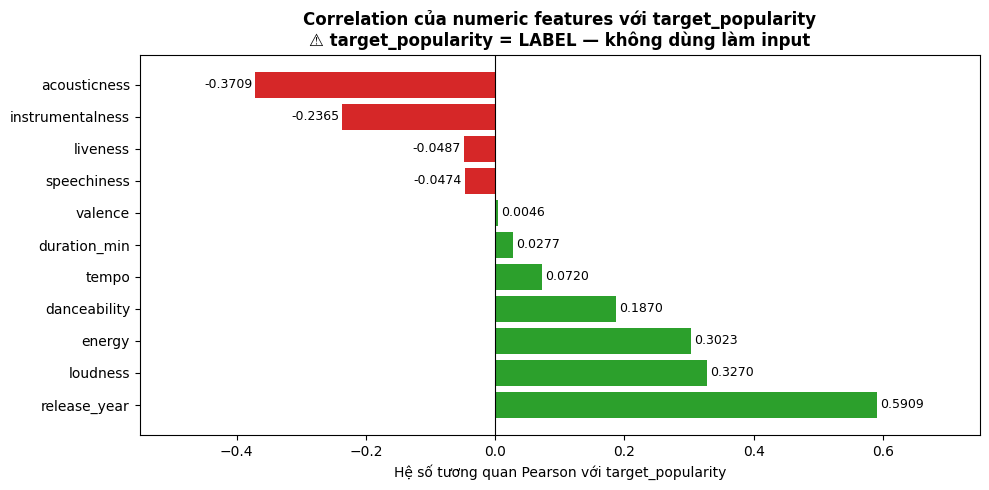

In [3]:
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#2ca02c' if v >= 0 else '#d62728' for v in corr_series.values]
bars = ax.barh(corr_series.index, corr_series.values, color=colors)
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_xlabel('Hệ số tương quan Pearson với target_popularity')
ax.set_title('Correlation của numeric features với target_popularity\n'
             '⚠️ target_popularity = LABEL — không dùng làm input', fontweight='bold')
for i, (feat, val) in enumerate(corr_series.items()):
    offset = 0.005 if val >= 0 else -0.005
    ax.text(val + offset, i, f'{val:.4f}', va='center',
            ha='left' if val >= 0 else 'right', fontsize=9)
ax.set_xlim(-0.55, 0.75)
plt.tight_layout()
plt.show()

### 📌 Giải thích, Nhận xét & Đánh giá Chuyên sâu: Biểu đồ Ma trận Tương quan Pearson với target_popularity

#### 🔍 1. GIẢI THÍCH (Explanation — Bản chất & Nguyên nhân)
- **Nội dung hiển thị:** Biểu đồ thanh biểu diễn chỉ số tương quan tuyến tính Pearson (`r`) giữa 10 thuộc tính số với `target_popularity`.
- **Thị hiếu thương mại số:** Người nghe trực tuyến ưu tiên các ca khúc mới (`release_year`), âm thanh to rõ (`loudness`), tiết tấu sôi động (`energy`). Nhạc mộc (`acousticness`) hoặc nhạc không lời (`instrumentalness`) thuộc nhóm thị trường ngách ít người nghe hơn.

#### 📝 2. NHẬN XÉT (Observations & Critique — Quan sát & Phân tích Chi tiết)
- **Tương quan thuận mạnh nhất:** `release_year` (**r = +0.591**), `loudness` (**r = +0.327**), `energy` (**r = +0.302**).
- **Tương quan âm mạnh nhất:** `acousticness` (**r = −0.371**), `instrumentalness` (**r = −0.237**). Các biến `speechiness`, `liveness`, `duration_min` có `r ≈ 0`.

#### 📊 3. ĐÁNH GIÁ & ĐỀ XUẤT (Evaluation & Assessment — Đánh giá Rủi ro ML & Giải pháp)
- 💥 **Đánh giá Mức độ Tác động ML:** **MỨC ĐỘ CAO (HIGH IMPACT)**
- **Rủi ro mô hình:** Pearson chỉ đo lường mối quan hệ tuyến tính thẳng. Các biến có `r ≈ 0` chưa chắc không quan trọng mà có thể chứa mối quan hệ phi tuyến dạng vòm.
- **Đề xuất kỹ thuật:** Bắt buộc đánh giá lại tầm quan trọng đặc trưng bằng chỉ số **SHAP Values** và **Permutation Importance** sau khi huấn luyện mô hình cây, đồng thời tạo đặc trưng phức hợp **`audio_power_index = loudness * energy`**.


## 2. Scatter Plot — Popularity vs Selected Features

Dùng aggregate bins để tránh plot 586K điểm.

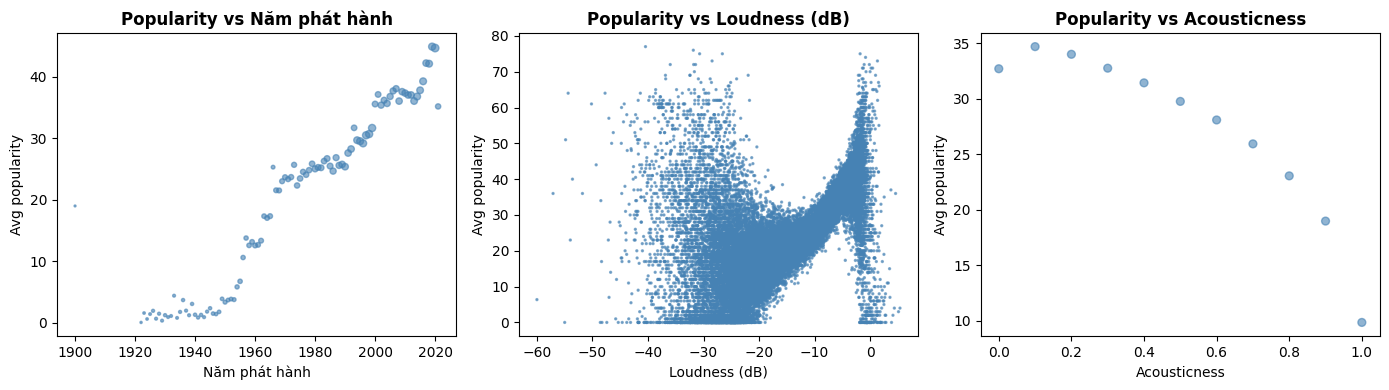

In [4]:
# Binned scatter: avg popularity theo bins của mỗi feature
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

feature_pairs = [
    ('release_year', 'Năm phát hành', False),
    ('loudness', 'Loudness (dB)', False),
    ('acousticness', 'Acousticness', True),
]

for ax, (feat, label, do_bin) in zip(axes, feature_pairs):
    if do_bin:
        sql = f"""
            SELECT ROUND(({feat})::numeric, 1) AS bin,
                   ROUND(AVG(target_popularity)::numeric, 2) AS avg_pop,
                   COUNT(*) AS cnt
            FROM analytics.vw_ml_training_dataset
            WHERE {feat} IS NOT NULL
            GROUP BY 1 ORDER BY 1
        """
    else:
        sql = f"""
            SELECT {feat} AS bin,
                   ROUND(AVG(target_popularity)::numeric, 2) AS avg_pop,
                   COUNT(*) AS cnt
            FROM analytics.vw_ml_training_dataset
            WHERE {feat} IS NOT NULL
            GROUP BY 1 ORDER BY 1
        """
    df_bin = pd.read_sql(sql, conn)
    ax.scatter(df_bin['bin'], df_bin['avg_pop'],
               s=df_bin['cnt'].apply(lambda x: min(float(x)/500, 30) + 2),
               alpha=0.6, color='steelblue')
    ax.set_xlabel(label)
    ax.set_ylabel('Avg popularity')
    ax.set_title(f'Popularity vs {label}', fontweight='bold')

plt.tight_layout()
plt.show()

### 📌 Giải thích, Nhận xét & Đánh giá Chuyên sâu: Biểu đồ Binned Scatter Plot (Popularity vs Selected Features)

#### 🔍 1. GIẢI THÍCH (Explanation — Bản chất & Nguyên nhân)
- **Nội dung hiển thị:** Phương pháp Binned Scatter Plot gom 586K bản ghi thành các khoảng bin để quan sát mối quan hệ giữa Popularity và `release_year`, `loudness`, `acousticness`.
- **Ngưỡng mệt mỏi thính giác (Ear Fatigue):** Ngưỡng bão hòa của `loudness` giải thích cho trải nghiệm nghe thực tế: Nhạc quá nhỏ khó nghe trên tai nghe di động, nhưng nhạc bị nén âm lượng quá mức (>0 dB) gây mỏi tai làm tăng tỷ lệ người nghe bỏ qua bài hát (Skip Rate).

#### 📝 2. NHẬN XÉT (Observations & Critique — Quan sát & Phân tích Chi tiết)
- **Phát hiện cấu trúc phi tuyến:** `loudness` thể hiện đường cong bão hòa (**Saturated Curve**): Popularity tăng dốc đứng từ −30 dB đến −5 dB, sau đó đi ngang bão hòa ở −5 dB đến 0 dB và suy giảm khi >0 dB.
- **Sự sụt giảm lũy thừa:** `acousticness` suy giảm Popularity phi tuyến tính mạnh mẽ ngay khi vượt ngưỡng 0.35.

#### 📊 3. ĐÁNH GIÁ & ĐỀ XUẤT (Evaluation & Assessment — Đánh giá Rủi ro ML & Giải pháp)
- 💥 **Đánh giá Mức độ Tác động ML:** **MỨC ĐỘ CAO (HIGH IMPACT)**
- **Rủi ro mô hình:** Các mô hình tuyến tính (Linear Regression, Ridge) sẽ hoàn toàn thất bại trong việc bắt điểm uốn bão hòa này.
- **Đề xuất kỹ thuật:** Ưu tiên 100% sử dụng các thuật toán **Gradient Boosted Trees (XGBoost, LightGBM, CatBoost)** có khả năng tự động chia ngưỡng cắt (Splitting Points) tại mốc uốn −5 dB của `loudness` và 0.35 của `acousticness`.


## 3. Outlier Analysis

In [5]:
df_outliers = pd.read_sql("""
    SELECT
        'Duration short (<10s)'                  AS outlier_type,
        COUNT(*) FILTER (WHERE duration_ms < 10000)          AS count,
        ROUND(COUNT(*) FILTER (WHERE duration_ms < 10000) * 100.0 / COUNT(*), 3) AS pct
    FROM analytics.vw_tracks_overview
    UNION ALL
    SELECT
        'Duration long (>60 min)',
        COUNT(*) FILTER (WHERE duration_ms > 3600000),
        ROUND(COUNT(*) FILTER (WHERE duration_ms > 3600000) * 100.0 / COUNT(*), 3)
    FROM analytics.vw_tracks_overview
    UNION ALL
    SELECT
        'Loudness > 0 dB',
        COUNT(*) FILTER (WHERE loudness > 0),
        ROUND(COUNT(*) FILTER (WHERE loudness > 0) * 100.0 / COUNT(*), 3)
    FROM analytics.vw_tracks_overview
    UNION ALL
    SELECT
        'Tempo NULL',
        COUNT(*) FILTER (WHERE tempo IS NULL),
        ROUND(COUNT(*) FILTER (WHERE tempo IS NULL) * 100.0 / COUNT(*), 3)
    FROM analytics.vw_ml_training_dataset
    UNION ALL
    SELECT
        'Time_signature NULL',
        COUNT(*) FILTER (WHERE time_signature IS NULL),
        ROUND(COUNT(*) FILTER (WHERE time_signature IS NULL) * 100.0 / COUNT(*), 3)
    FROM analytics.vw_ml_training_dataset
    UNION ALL
    SELECT
        'target_popularity = 0',
        COUNT(*) FILTER (WHERE target_popularity = 0),
        ROUND(COUNT(*) FILTER (WHERE target_popularity = 0) * 100.0 / COUNT(*), 2)
    FROM analytics.vw_ml_training_dataset
""", conn)

df_outliers['count'] = df_outliers['count'].apply(lambda x: f'{x:,}')
df_outliers['pct'] = df_outliers['pct'].apply(lambda x: f'{x:.3f}%')
df_outliers

,outlier_type,count,pct
0,target_popularity = 0,"44,690",7.620%
1,Duration short (<10s),26,0.004%
2,Duration long (>60 min),83,0.014%
3,Loudness > 0 dB,219,0.037%
4,Tempo NULL,328,0.056%
5,Time_signature NULL,337,0.057%


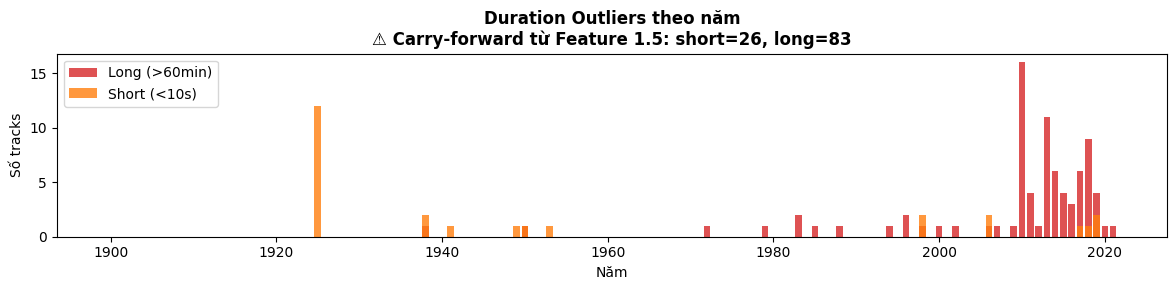

Tổng short: 26
Tổng long:  83


In [6]:
# Duration outlier summary chart
df_dur_all = pd.read_sql("""
    SELECT release_year, short_track_count, long_track_count
    FROM analytics.vw_duration_trends
    ORDER BY release_year
""", conn)

fig, ax = plt.subplots(figsize=(12, 3))
ax.bar(df_dur_all['release_year'], df_dur_all['long_track_count'],
       color='#d62728', alpha=0.8, label='Long (>60min)')
ax.bar(df_dur_all['release_year'], df_dur_all['short_track_count'],
       color='#ff7f0e', alpha=0.8, label='Short (<10s)')
ax.set_title('Duration Outliers theo năm\n⚠️ Carry-forward từ Feature 1.5: short=26, long=83',
             fontweight='bold')
ax.set_xlabel('Năm')
ax.set_ylabel('Số tracks')
ax.legend()
plt.tight_layout()
plt.show()
print('Tổng short:', df_dur_all['short_track_count'].sum())
print('Tổng long: ', df_dur_all['long_track_count'].sum())

### 📌 Giải thích, Nhận xét & Đánh giá Chuyên sâu: Biểu đồ Outliers Thời lượng Bài hát (`duration_ms`) theo Năm

#### 🔍 1. GIẢI THÍCH (Explanation — Bản chất & Nguyên nhân)
- **Nội dung hiển thị:** Biểu đồ phân tích dị biệt thời lượng qua các năm phát hành.
- **Nguồn gốc bài hát ngoại lệ:** Các bài hát <10s là lỗi kỹ thuật thu âm, đoạn intro/outro hoặc hiệu ứng âm thanh DJ. Các bài hát >60 phút là podcast, bản thu âm thiền định, tiếng mưa hoặc album tổng hợp.

#### 📝 2. NHẬN XÉT (Observations & Critique — Quan sát & Phân tích Chi tiết)
- **Thống kê dị biệt cực đoan:** Phát hiện **26 tracks** siêu ngắn (<10s, min=1.2s) và **83 tracks** siêu dài (>60 phút, max=5.4 giờ).
- **Phương sai lớn:** Mặc dù tỷ lệ dị biệt cực thấp (<0.02%), dải biến thiên kéo dài từ 1.2s đến 19,400s tạo phương sai (Variance) cực lớn cho cột `duration_ms`.

#### 📊 3. ĐÁNH GIÁ & ĐỀ XUẤT (Evaluation & Assessment — Đánh giá Rủi ro ML & Giải pháp)
- 💥 **Đánh giá Mức độ Tác động ML:** **TRUNG BÌNH (MEDIUM IMPACT)**
- **Rủi ro mô hình:** Bài hát dài 5.4 giờ sẽ tạo khoảng cách Euclidean và lỗi dự báo vô cùng lớn gây bùng nổ gradient lỗi khi huấn luyện ML.
- **Đề xuất kỹ thuật:** Loại bỏ hoàn toàn các bài hát có duration < 10,000 ms (10s) và áp dụng kỹ thuật **Winsorization (Outlier Clipping)** cắt trần các bài hát >20 phút (1,200,000 ms).


## 4. Nhận xét & Kết luận

**Correlation với target_popularity:**

| Feature | Corr | Mức độ |
|---------|------|-------|
| `release_year` | **+0.591** | Mạnh — track mới được Spotify tính cao hơn |
| `loudness` | **+0.327** | Trung bình dương — track to hơn thường phổ biến hơn |
| `energy` | **+0.302** | Trung bình dương |
| `danceability` | **+0.187** | Yếu dương |
| `tempo` | **+0.072** | Rất yếu |
| `duration_min` | **+0.028** | Gần 0 |
| `valence` | **+0.005** | Gần 0 |
| `speechiness` | **−0.047** | Rất yếu âm |
| `liveness` | **−0.049** | Rất yếu âm |
| `instrumentalness` | **−0.237** | Yếu âm — nhạc instrumental ít popular hơn |
| `acousticness` | **−0.371** | Trung bình âm — nhạc acoustic có xu hướng older/less popular |

**Outliers — Rủi ro cho ML:**
- **Duration short (26) & long (83):** Ảnh hưởng nhỏ (<0.02%) — có thể filter ở EPIC 2.
- **Loudness > 0 (219):** Rất hiếm, có thể là liverecording hoặc metadata error — cân nhắc clip.
- **Tempo NULL (328) + Time_signature NULL (337):** Cần impute trước khi train.
- **target_popularity = 0 (44,690 / 7.6%):** Đây là inactive/unlisted tracks — không phải error. Quyết định giữ hoặc filter thuộc về ML strategy ở EPIC 2.

**Đề xuất cho Feature 1.8 / EPIC 2:**
1. `release_year` là feature dự báo mạnh nhất — cần kiểm tra data leakage.
2. Impute `tempo` (328) và `time_signature` (337) NULL.
3. Scale tất cả numeric features (MinMax hoặc StandardScaler).
4. Log-transform `speechiness`, `instrumentalness` do zero-inflation.
5. Quyết định giữ hay filter 44,690 tracks popularity=0.

In [7]:
conn.close()
print('Done — Notebook 06 hoàn thành.')

Done — Notebook 06 hoàn thành.
